In [2]:
import numpy as np
import matplotlib.pyplot as plt
import time
from tensorflow.keras.models import Sequential
from tensorflow.keras.layers import SimpleRNN, LSTM, GRU, Dense

In [4]:
# Generate sine wave dataset
t = np.linspace(0, 100, 1000)
data = np.sin(t)

# Create sequences
def create_dataset(data, time_steps=10):
    X, y = [], []
    for i in range(len(data) - time_steps):
        X.append(data[i:i+time_steps])
        y.append(data[i+time_steps])
    return np.array(X), np.array(y)

X, y = create_dataset(data)
X = X.reshape((X.shape[0], X.shape[1], 1))

histories = {}
times = {}

def build_model(model_type):
    model = Sequential()
    if model_type == "RNN":
        model.add(SimpleRNN(32, input_shape=(10,1)))
    elif model_type == "LSTM":
        model.add(LSTM(32, input_shape=(10,1)))
    elif model_type == "GRU":
        model.add(GRU(32, input_shape=(10,1)))
    model.add(Dense(1))
    model.compile(optimizer='adam', loss='mse')
    return model

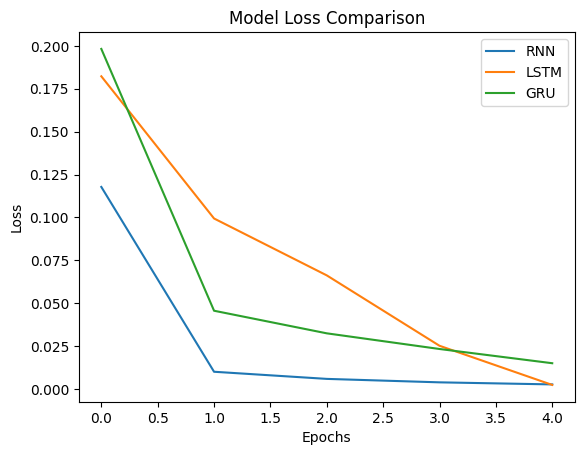

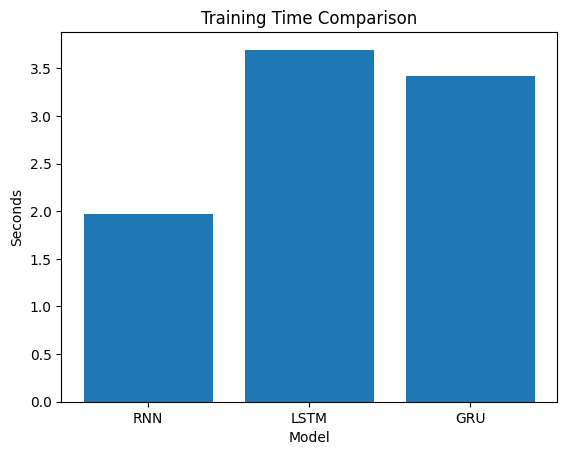

In [5]:
# Train models
for m in ["RNN", "LSTM", "GRU"]:
    model = build_model(m)
    start = time.time()
    history = model.fit(X, y, epochs=5, batch_size=32, verbose=0)
    end = time.time()

    histories[m] = history.history['loss']
    times[m] = end - start

# Plot Loss
for m in histories:
    plt.plot(histories[m], label=m)
plt.title("Model Loss Comparison")
plt.xlabel("Epochs")
plt.ylabel("Loss")
plt.legend()
plt.show()

# Plot Training Time
plt.bar(times.keys(), times.values())
plt.title("Training Time Comparison")
plt.xlabel("Model")
plt.ylabel("Seconds")
plt.show()